In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

In [2]:
from progsnap2.analytics.analytics_config import Granularity
from progsnap2.datasets import codeworkout, edwards, codebench, cs1eng

# Select a dataset by setting the config variable
config = cs1eng.S24

datasets_dir = os.path.join('..', '..', '..', 'sample_data')
dataset_paths = {
    # Edwards 2019 datasets is split into two semesters
    'edwards_f19': os.path.join(datasets_dir, 'edwards', '2019'),
    'edwards_s19': os.path.join(datasets_dir, 'edwards', '2019'),
}

if config.name in dataset_paths:
    dataset_root_dir = dataset_paths[config.name]
else:
    # Most datasets follow a simple naming convention
    dataset_name, dataset_semester = config.name.split('_')
    dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)

dataset = config.load(dataset_root_dir)

In [5]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [6]:
main_table = dataset.get_main_table()
main_table.head()

ValueError: Table MainTable not found

In [25]:
if config.start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= config.start_time]
if config.end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= config.end_time]

In [26]:
# Used for converting percentages to raw early time when
# creating a dataset config; not needed when using existing configs
min = main_table[timestamp_col].min()
max = main_table[timestamp_col].max()
min + (max - min) * 0.29

Timestamp('2024-02-11 11:58:25.179999999')

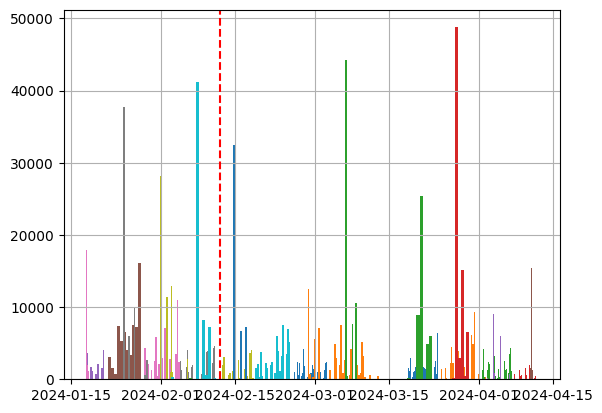

In [27]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
early_timestamp = pd.to_datetime(config.early_time)
if early_timestamp is None:
    print("Warning: No early time cutoff specified")
if Cols.CourseSectionID not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
    if early_timestamp is not None:
        plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
else:
    classes = main_table[Cols.CourseSectionID].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table[Cols.CourseSectionID] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        if early_timestamp is not None:
            plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
        plt.show()

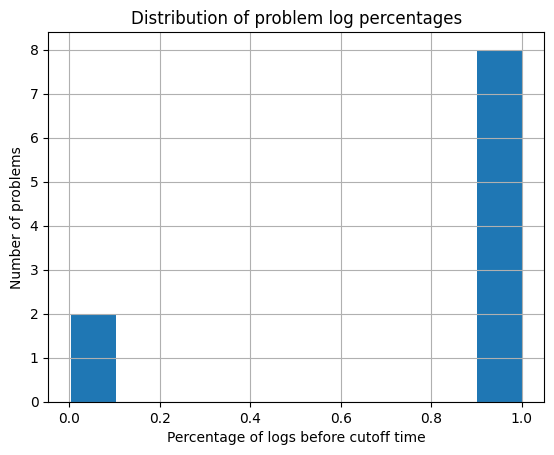

Removing partial problems: Index(['homework6', 'inlab11'], dtype='object', name='ProblemID')
This removed 0.15% of data
Semester start 2024-01-17 18:59:34
Semester end 2024-04-11 23:45:16
Early cutoff time 2024-02-12 00:00:00
Early Problem IDs: ['inlab2' 'homework2' 'homework3' 'inlab3' 'homework4' 'inlab4' 'inlab5'
 'homework5']
Total number of rows: 442562
Percent of logs:  35.99062829613738
Problems: 8 / 23


In [28]:
from progsnap2.analytics.preprocessors.early_cutoff import filter_before_time

data_subset = filter_before_time(main_table, config.early_time, timestamp_col, filter_problems=True, verbose=True)

In [29]:
# We want to analyze each student's attempt at each problem, and we also
# want to analyze data separately from each course section.
grouping_cols = config.attempt_grouping_columns
grouping_cols = [col for col in grouping_cols if col in main_table.columns]
grouping_cols

[<MainTableColumns.SubjectID: 'SubjectID'>,
 <MainTableColumns.ProblemID: 'ProblemID'>]

In [30]:
from progsnap2.analytics.metrics.errors import ErrorMetrics

error_results = None

if Cols.ParentEventID in data_subset.columns:
    error_metrics = ErrorMetrics(True,
                                compile_message_type_column=config.compile_error_type_column,
                                compile_event=config.compile_event,
                                compile_error_event=config.compile_error_event)

    error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
    error_results.head()

In [31]:
if error_results is not None:
    # Distribution of each error metric across students/problems
    error_results.describe()

In [32]:
if error_results is not None:
    # Correlate the metrics
    error_results.corr(method="spearman")

<Axes: ylabel='Frequency'>

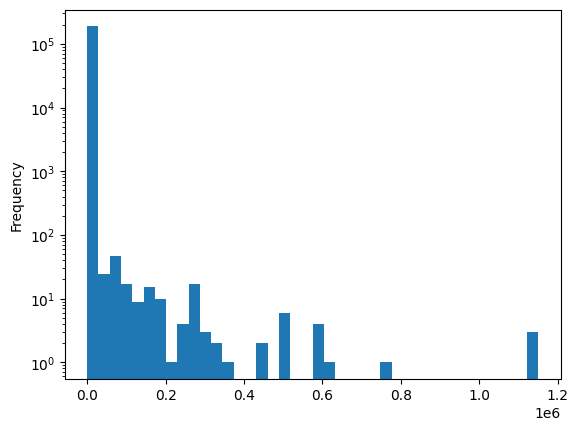

In [33]:
from progsnap2.analytics.metrics.time import TimeMetrics

# Out of curisosity, how far apart are events in this dataset (in seconds)?
diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [34]:
# Determine a gap to be considered idle time or taking a break based
# on the type of dataset. Can confirm with the histogram above if it makes sense
idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")


In [35]:
from progsnap2.analytics.metrics.time import TimeMetrics
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
time_results

C:\Users\twprice\AppData\Local\Temp\ipykernel_25052\1574692767.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
SubjectID      ProblemID                                       
 Passion Fruit homework2      1260.0        644.0     1904.0   
               homework3      1347.0        872.0     2219.0   
               homework4      2417.0       1217.0     3634.0   
               homework5       878.0       1101.0     1979.0   
               inlab2          700.0        253.0      953.0   
...                              ...          ...        ...   
Watermelon     inlab5          708.0        838.0     1546.0   
White Currant  homework3         0.0          0.0        0.0   
               homework4         0.0          0.0        0.0   
               homework5        59.0         68.0      127.0   
               inlab3           70.0         79.0      149.0   

                          ActiveTimeAfterCorrect  #Breaks           StartTime  \
SubjectID      ProblemID                                                        
 Passion Fruit homework2                   412.0        2 2024-01-18 22:19:18   
               homework3                   572.0        2 2024-01-25 17:48:43   
               homework4                   188.0        3 2024-01-31 23:50:29   
               homework5                   159.0        1 2024-02-10 21:03:26   
               inlab2                        0.0        0 2024-01-17 22:07:04   
...                                          ...      ...                 ...   
Watermelon     inlab5                        0.0        4 2024-02-07 18:27:51   
White Currant  homework3                   334.0        0 2024-01-28 03:41:04   
               homework4                    57.0        0 2024-02-04 04:57:10   
               homework5                    46.0        1 2024-02-11 03:31:26   
               inlab3                      685.0        0 2024-01-26 20:16:16   

                            FirstCorrectTime             EndTime  
SubjectID      ProblemID                                          
 Passion Fruit homework2 2024-01-20 23:44:58 2024-01-25 17:42:54  
               homework3 2024-01-27 23:26:16 2024-01-29 17:07:45  
               homework4 2024-02-04 01:25:05 2024-02-04 02:07:34  
               homework5 2024-02-10 21:52:59 2024-02-10 22:03:24  
               inlab2                    NaT 2024-01-17 22:22:57  
...                                      ...                 ...  
Watermelon     inlab5                    NaT 2024-02-07 19:42:27  
White Currant  homework3 2024-01-28 03:41:04 2024-01-28 03:58:54  
               homework4 2024-02-04 04:57:10 2024-02-04 04:58:56  
               homework5 2024-02-11 04:00:48 2024-02-11 04:01:57  
               inlab3    2024-01-26 20:18:45 2024-01-26 20:45:28  

[379 rows x 8 columns]

In [36]:
time_results.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,379.000000,379.000000,379.000000,379.000000,379.000000,379,304,379
mean,1085.488127,794.707124,1880.195251,148.548813,2.427441,2024-01-29 07:31:16.395778304,2024-01-30 02:10:04.575657728,2024-01-30 07:41:22.609498624
min,0.000000,0.000000,0.000000,0.000000,0.000000,2024-01-17 18:59:34,2024-01-17 19:43:42,2024-01-17 19:16:48
25%,344.500000,179.500000,573.000000,0.000000,0.000000,2024-01-24 13:50:36,2024-01-24 20:09:55,2024-01-24 20:14:14.500000
50%,852.000000,592.000000,1432.000000,16.000000,1.000000,2024-01-29 23:15:53,2024-01-30 08:18:21.500000,2024-01-31 19:46:57
75%,1562.500000,1057.500000,2720.500000,188.500000,3.000000,2024-02-05 18:20:50,2024-02-06 18:01:57,2024-02-06 20:08:40
max,6857.000000,4757.000000,10985.000000,2782.000000,16.000000,2024-02-11 03:31:26,2024-02-11 04:00:48,2024-02-11 20:40:59
std,991.829242,836.058627,1761.698987,301.284735,3.170947,NaN,NaN,NaN


In [37]:
time_results.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.882878,0.976318,0.068138,0.611957,0.323876,0.240716,0.357750
PassiveTime,0.882878,1.000000,0.960295,0.031926,0.648941,0.321737,0.220118,0.359931
TotalTime,0.976318,0.960295,1.000000,0.046946,0.645738,0.335005,0.237190,0.372241
ActiveTimeAfterCorrect,0.068138,0.031926,0.046946,1.000000,-0.042329,0.058725,0.352376,0.070360
#Breaks,0.611957,0.648941,0.645738,-0.042329,1.000000,0.228897,0.097589,0.329653
StartTime,0.323876,0.321737,0.335005,0.058725,0.228897,1.000000,0.681328,0.956489
FirstCorrectTime,0.240716,0.220118,0.237190,0.352376,0.097589,0.681328,1.000000,0.658524
EndTime,0.357750,0.359931,0.372241,0.070360,0.329653,0.956489,0.658524,1.000000


In [38]:
from progsnap2.analytics.metrics.score import SubmissionScoreMetrics
from progsnap2.spec.enums import EventType

score_metrics = SubmissionScoreMetrics(config.submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_25052\3695921909.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [39]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  Attempted  \
SubjectID     ProblemID                                                   
Passion Fruit homework2         7         False         True       True   
              homework3         4         False         True       True   
              homework4        11         False         True       True   
              homework5        10         False         True       True   
              inlab2            3         False        False       True   

                         MaxScore  MinScore  MeanScore  TotalAttempts  
SubjectID     ProblemID                                                
Passion Fruit homework2  1.000000  0.166667   0.285714             17  
              homework3  1.000000  0.166667   0.375000              9  
              homework4  1.000000  0.166667   0.393939             22  
              homework5  1.000000  0.166667   0.250000             18  
              inlab2     0.166667  0.166667   0.166667              3

In [40]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,379.000000,379.000000,379.000000,379.000000,379.000000
mean,18.240106,0.865076,0.277525,0.440388,21.957784
std,27.510323,0.295107,0.302701,0.279842,30.761900
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.000000,0.166667,0.212963,7.000000
50%,11.000000,1.000000,0.166667,0.361111,15.000000
75%,24.000000,1.000000,0.166667,0.583333,27.000000
max,398.000000,1.000000,1.000000,1.000000,460.000000


In [41]:
all_features = pd.merge(
    time_results.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,Passion Fruit,homework2,1260.0,644.0,1904.0,412.0,2,2024-01-18 22:19:18,2024-01-20 23:44:58,2024-01-25 17:42:54,7,False,True,True,1.000000,0.166667,0.285714,17
1,Passion Fruit,homework3,1347.0,872.0,2219.0,572.0,2,2024-01-25 17:48:43,2024-01-27 23:26:16,2024-01-29 17:07:45,4,False,True,True,1.000000,0.166667,0.375000,9
2,Passion Fruit,homework4,2417.0,1217.0,3634.0,188.0,3,2024-01-31 23:50:29,2024-02-04 01:25:05,2024-02-04 02:07:34,11,False,True,True,1.000000,0.166667,0.393939,22
3,Passion Fruit,homework5,878.0,1101.0,1979.0,159.0,1,2024-02-10 21:03:26,2024-02-10 21:52:59,2024-02-10 22:03:24,10,False,True,True,1.000000,0.166667,0.250000,18
4,Passion Fruit,inlab2,700.0,253.0,953.0,0.0,0,2024-01-17 22:07:04,NaT,2024-01-17 22:22:57,3,False,False,True,0.166667,0.166667,0.166667,3


In [42]:
# Some features are NA for some students, e.g. because
# they never got a problem right (no FirstCorrectTime) or
# because they only compiled once and errors metrics are undefined.
all_features.isna().mean()

SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.197889
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
dtype: float64

In [43]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)

# We can calculate a few custom metrics
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,379.000000,379.000000,379.000000,379.000000,379.000000,379,304,379,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000
mean,1085.488127,794.707124,1880.195251,148.548813,2.427441,2024-01-29 07:31:16.395778304,2024-01-30 02:10:04.575657728,2024-01-30 07:41:22.609498624,18.240106,0.865076,0.277525,0.440388,21.957784,0.503958,0.873351,0.926121
min,0.000000,0.000000,0.000000,0.000000,0.000000,2024-01-17 18:59:34,2024-01-17 19:43:42,2024-01-17 19:16:48,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,344.500000,179.500000,573.000000,0.000000,0.000000,2024-01-24 13:50:36,2024-01-24 20:09:55,2024-01-24 20:14:14.500000,4.000000,1.000000,0.166667,0.212963,7.000000,0.000000,1.000000,1.000000
50%,852.000000,592.000000,1432.000000,16.000000,1.000000,2024-01-29 23:15:53,2024-01-30 08:18:21.500000,2024-01-31 19:46:57,11.000000,1.000000,0.166667,0.361111,15.000000,1.000000,1.000000,1.000000
75%,1562.500000,1057.500000,2720.500000,188.500000,3.000000,2024-02-05 18:20:50,2024-02-06 18:01:57,2024-02-06 20:08:40,24.000000,1.000000,0.166667,0.583333,27.000000,1.000000,1.000000,1.000000
max,6857.000000,4757.000000,10985.000000,2782.000000,16.000000,2024-02-11 03:31:26,2024-02-11 04:00:48,2024-02-11 20:40:59,398.000000,1.000000,1.000000,1.000000,460.000000,1.000000,1.000000,1.000000
std,991.829242,836.058627,1761.698987,301.284735,3.170947,NaN,NaN,NaN,27.510323,0.295107,0.302701,0.279842,30.761900,0.500645,0.333019,0.261919


In [44]:
# Let's take the z-score per problem for each numeric feature to
# normalize the features before combining across problems.
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [45]:
all_features_z.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Passion Fruit,homework2,2.815684,1.378043,2.225294,2.923711,2.322328,-0.406223,0.715004,1.645119,...,False,True,True,0.000000,-0.962102,-1.247063,1.367346,0.962102,0.000000,0.000000
1,Passion Fruit,homework3,0.173264,-0.063205,0.061599,0.992174,-0.501001,0.057559,0.432092,0.950133,...,False,True,True,0.425602,-0.418050,-0.009225,-0.727957,0.989949,0.432049,0.250106
2,Passion Fruit,homework4,1.440517,0.500816,1.033491,-0.068596,-0.078499,-0.140295,0.323074,1.021858,...,False,True,True,0.304132,-0.542105,-0.736603,0.221365,0.990338,0.323013,0.198068
3,Passion Fruit,homework5,-0.420726,-0.091841,-0.268859,0.033233,-0.785734,1.426276,0.413195,0.953716,...,False,True,True,0.392202,-0.240279,-0.175368,-0.343557,-0.990697,0.413149,0.316467
4,Passion Fruit,inlab2,0.366703,-0.431493,-0.084364,-0.413413,-0.802643,-0.420186,-0.814944,-0.514432,...,False,False,True,-0.812079,-0.283824,-0.508699,-0.745700,0.968475,0.145865,0.145865


In [50]:
merge_cols = grouping_cols.copy()
merge_cols = [col for col in merge_cols if col not in [Cols.ProblemID, Cols.AssignmentID]]
merge_cols = [col for col in merge_cols if col in all_features_z.columns]
drop_cols = [col for col in [Cols.ProblemID, Cols.AssignmentID] if col in all_features_z.columns]

# Take the average across all problems for each student
subject_means = all_features_z.drop(drop_cols, axis=1).groupby(merge_cols).mean()

# Sometimes there are no non-NA values for a student across all problems for a given
# feature and we need to deal with that.

# For EQ and RED having no attempts with a successful compile (and therefore a score)
# should give you the max (worst) value
for col in [ErrorMetrics.ERROR_QUOTIENT, ErrorMetrics.REPEATED_ERROR_DENSITY]:
    if col not in subject_means.columns:
        continue
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for score metrics, not trying a problem should lead to the minimum value
for col in [SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,
Passion Fruit,0.875089,0.258464,0.593432,0.693422,0.030890,0.103426,0.213684,0.811279,-0.344297,0.000000,0.800000,1.000,0.061971,-0.489272,-0.535392,-0.045701,0.584033,0.262815,0.182101
Acerola Cherry,-0.491926,-0.701188,-0.622145,0.166407,-0.193855,1.043080,0.264235,0.447868,-0.720393,0.250000,0.875000,0.875,0.058678,0.374375,0.369958,-0.732418,-0.750332,0.031614,-0.105134
Ackee,-0.705926,-0.662659,-0.720804,0.332604,-0.602141,0.027919,0.082809,-0.423581,-0.640035,0.333333,0.833333,1.000,-0.008799,0.497738,0.732993,-0.374306,-0.993257,-0.093032,-0.325835
Apple,-0.365644,-0.090010,-0.256734,0.327787,-0.190765,-0.834637,-0.082966,-0.815120,-0.455895,0.000000,0.857143,1.000,0.089692,-0.197235,0.038753,-0.352864,-0.147976,0.077794,-0.082627
Apricot,-0.423474,-0.208400,-0.333801,-0.393014,0.036087,0.428940,0.318335,0.355756,-0.310952,0.250000,0.875000,1.000,0.190391,0.373772,0.312082,-0.374413,-0.503236,0.340623,0.235904


In [52]:
# We can also take the sum of features across problems, which treats
# missing problems differently than the mean.
subject_totals = all_features_z.drop(drop_cols, axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,
Passion Fruit,4.375443,1.292320,2.967160,3.467109,0.154451,0.517131,1.068420,4.056393,-1.721483,0,4,5,0.309857,-2.446361,-2.676958,-0.228504,2.920167,1.314076,0.910506
Acerola Cherry,-3.935406,-5.609504,-4.977162,1.331259,-1.550836,8.344638,2.113880,3.582941,-5.763142,2,7,7,0.469422,2.995000,2.959663,-5.859347,-6.002654,0.252914,-0.841068
Ackee,-4.235555,-3.975953,-4.324826,1.995624,-3.612844,0.167514,0.496855,-2.541484,-3.840212,2,5,6,-0.052795,2.986430,4.397958,-2.245834,-5.959540,-0.558191,-1.955013
Apple,-2.559509,-0.630073,-1.797135,2.294510,-1.335357,-5.842459,-0.580760,-5.705837,-3.191266,0,6,7,0.627845,-1.380648,0.271269,-2.470051,-1.035835,0.544558,-0.578388
Apricot,-3.387789,-1.667201,-2.670409,-3.144111,0.288696,3.431516,2.546683,2.846044,-2.487616,2,7,8,1.523128,2.990179,2.496657,-2.995307,-4.025888,2.724980,1.887229


In [53]:
# Lets merge the means and totals into a single DataFrame
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Passion Fruit,0.875089,0.258464,0.593432,0.693422,0.030890,0.103426,0.213684,0.811279,-0.344297,...,0,4,5,0.309857,-2.446361,-2.676958,-0.228504,2.920167,1.314076,0.910506
1,Acerola Cherry,-0.491926,-0.701188,-0.622145,0.166407,-0.193855,1.043080,0.264235,0.447868,-0.720393,...,2,7,7,0.469422,2.995000,2.959663,-5.859347,-6.002654,0.252914,-0.841068
2,Ackee,-0.705926,-0.662659,-0.720804,0.332604,-0.602141,0.027919,0.082809,-0.423581,-0.640035,...,2,5,6,-0.052795,2.986430,4.397958,-2.245834,-5.959540,-0.558191,-1.955013
3,Apple,-0.365644,-0.090010,-0.256734,0.327787,-0.190765,-0.834637,-0.082966,-0.815120,-0.455895,...,0,6,7,0.627845,-1.380648,0.271269,-2.470051,-1.035835,0.544558,-0.578388
4,Apricot,-0.423474,-0.208400,-0.333801,-0.393014,0.036087,0.428940,0.318335,0.355756,-0.310952,...,2,7,8,1.523128,2.990179,2.496657,-2.995307,-4.025888,2.724980,1.887229


In [54]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [55]:
# No feature should be NA at this point
assert subject_features.isna().mean().mean() == 0

In [56]:
# Take one last z-score across all students for each numeric feature
# This makes means and sums more comparable across students
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Passion Fruit,1.701556,0.451153,1.115622,1.554326,0.024241,0.116226,0.504041,1.343080,-0.544138,...,-0.891164,-0.803832,-0.994490,0.108753,-0.747467,-0.719715,-0.062205,0.828719,0.450992,0.386005
1,Acerola Cherry,-0.871233,-1.227171,-1.111274,0.381027,-0.356764,1.574696,0.617236,0.735870,-1.101808,...,1.028266,0.884216,0.165748,0.164757,0.915099,0.795722,-1.595082,-1.703503,0.086800,-0.356568
2,Ackee,-1.273992,-1.159788,-1.292014,0.751033,-1.048923,-0.000972,0.210984,-0.720199,-0.982655,...,1.028266,-0.241150,-0.414371,-0.018530,0.912481,1.182415,-0.611380,-1.691267,-0.191572,-0.828820
3,Apple,-0.633565,-0.158289,-0.441853,0.740309,-0.351527,-1.339776,-0.160222,-1.374406,-0.709615,...,-0.891164,0.321533,0.165748,0.220359,-0.421847,0.072932,-0.672419,-0.293961,0.186893,-0.245205
4,Apricot,-0.742402,-0.365340,-0.583038,-0.864420,0.033051,0.621467,0.738378,0.581964,-0.494695,...,1.028266,0.884216,0.745868,0.534584,0.913626,0.671240,-0.815408,-1.142513,0.935215,0.800084


In [58]:
# Get the grades to compare features to
grades = dataset.get_link_table(config.grades_link_table_name)
grades.head()

,SubjectID,IsInterventionGroup,MidtermExamGrade,FinalExamGrade,CourseGrade
0,Cherry,0,71.65,78.4,86.68
1,Apple,0,84.30,81.2,93.94
2,Ackee,1,98.50,98.2,99.38
3,Date,1,97.60,93.4,95.65
4,Apricot,0,63.05,64.3,87.37


In [59]:
grades.rename(columns={
    config.final_grade_column: "Grade",
}, inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 0 rows with 0 grades


In [60]:
grade_merge_cols = [col for col in merge_cols if col in grades.columns]
print(f"Merging on columns: {grade_merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[grade_merge_cols + ["Grade"]],
    on=grade_merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [61]:
print(subject_features.shape)
subject_feautres_labeled.head()

(56, 39)


,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Passion Fruit,1.701556,0.451153,1.115622,1.554326,0.024241,0.116226,0.504041,1.343080,-0.544138,...,-0.803832,-0.994490,0.108753,-0.747467,-0.719715,-0.062205,0.828719,0.450992,0.386005,71.9
1,Acerola Cherry,-0.871233,-1.227171,-1.111274,0.381027,-0.356764,1.574696,0.617236,0.735870,-1.101808,...,0.884216,0.165748,0.164757,0.915099,0.795722,-1.595082,-1.703503,0.086800,-0.356568,77.9
2,Ackee,-1.273992,-1.159788,-1.292014,0.751033,-1.048923,-0.000972,0.210984,-0.720199,-0.982655,...,-0.241150,-0.414371,-0.018530,0.912481,1.182415,-0.611380,-1.691267,-0.191572,-0.828820,98.2
3,Apple,-0.633565,-0.158289,-0.441853,0.740309,-0.351527,-1.339776,-0.160222,-1.374406,-0.709615,...,0.321533,0.165748,0.220359,-0.421847,0.072932,-0.672419,-0.293961,0.186893,-0.245205,81.2
4,Apricot,-0.742402,-0.365340,-0.583038,-0.864420,0.033051,0.621467,0.738378,0.581964,-0.494695,...,0.884216,0.745868,0.534584,0.913626,0.671240,-0.815408,-1.142513,0.935215,0.800084,64.3


In [62]:
subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().describe()

count    56.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: Grade, dtype: float64

In [63]:
assert subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().max() == 1

In [64]:

out_dir = os.path.join("..", "..", "..", "analysis", "features")
print(len(subject_feautres_labeled))
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
subject_feautres_labeled.to_csv(os.path.join(out_dir, f"{config.name}.csv"), index=False)

56
